In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

from numpy import asarray
from numpy import mean
from numpy import std
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from matplotlib import pyplot

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier
import xgboost

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
##val = pd.read_parquet('data/val.parquet')

In [8]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'cluster', 'cluster112', 'dist_centroid_0',
          'dist_centroid_1', 'dist_centroid_2', 'dist_centroid_3', 'dist_centroid_4',
          'dist_centroid_5', 'dist_centroid_6', 'dist_centroid_7', 'dist_centroid_8',
          'dist_centroid_9', 'dist_centroid_10', 'dist_centroid_11', 'dist_centroid_12',
          'dist_centroid_13', 'dist_centroid_14', 'dist_centroid_15', 'dist_centroid_16','dist_centroid_17',
          'dist_centroid_silhouette_1', 'dist_centroid_silhouette_2', 'dist_centroid_silhouette_3',
          'dist_centroid_silhouette_4', 'dist_centroid_silhouette_5', 'dist_centroid_silhouette_6',
          'dist_centroid_silhouette_7','dist_centroid_silhouette_8','dist_centroid_silhouette_9',
          'dist_centroid_silhouette_10','dist_centroid_silhouette_11','dist_centroid_silhouette_12',
          'dist_centroid_silhouette_13','dist_centroid_silhouette_14','dist_centroid_silhouette_15',
          'dist_centroid_silhouette_16','dist_centroid_silhouette_17','dist_centroid_silhouette_18',
          'dist_centroid_silhouette_19','dist_centroid_silhouette_20','dist_centroid_silhouette_21',
          'dist_centroid_silhouette_22','dist_centroid_silhouette_23','dist_centroid_silhouette_24',
          'dist_centroid_silhouette_25','dist_centroid_silhouette_26','dist_centroid_silhouette_27',
          'dist_centroid_silhouette_28','dist_centroid_silhouette_29','dist_centroid_silhouette_30',
          'dist_centroid_silhouette_31','dist_centroid_silhouette_32','dist_centroid_silhouette_33',
          'dist_centroid_silhouette_34','dist_centroid_silhouette_35','dist_centroid_silhouette_36',
          'dist_centroid_silhouette_37','dist_centroid_silhouette_38','dist_centroid_silhouette_39',
          'dist_centroid_silhouette_40','dist_centroid_silhouette_41','dist_centroid_silhouette_42',
          'dist_centroid_silhouette_43','dist_centroid_silhouette_44','dist_centroid_silhouette_45',
          'dist_centroid_silhouette_46','dist_centroid_silhouette_47','dist_centroid_silhouette_48',
          'dist_centroid_silhouette_49','dist_centroid_silhouette_50','dist_centroid_silhouette_51',
          'dist_centroid_silhouette_52','dist_centroid_silhouette_53','dist_centroid_silhouette_54',
 'dist_centroid_silhouette_55',
 'dist_centroid_silhouette_56',
 'dist_centroid_silhouette_57',
 'dist_centroid_silhouette_58',
 'dist_centroid_silhouette_59',
 'dist_centroid_silhouette_60',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_62',
 'dist_centroid_silhouette_63',
 'dist_centroid_silhouette_64',
 'dist_centroid_silhouette_65',
 'dist_centroid_silhouette_66',
 'dist_centroid_silhouette_67',
 'dist_centroid_silhouette_68',
 'dist_centroid_silhouette_69',
 'dist_centroid_silhouette_70',
 'dist_centroid_silhouette_71',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_73',
 'dist_centroid_silhouette_74',
 'dist_centroid_silhouette_75',
 'dist_centroid_silhouette_76',
 'dist_centroid_silhouette_77',
 'dist_centroid_silhouette_78',
 'dist_centroid_silhouette_79',
 'dist_centroid_silhouette_80',
 'dist_centroid_silhouette_81',
 'dist_centroid_silhouette_82',
 'dist_centroid_silhouette_83',
 'dist_centroid_silhouette_84',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_86',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_88',
 'dist_centroid_silhouette_89',
 'dist_centroid_silhouette_90',
 'dist_centroid_silhouette_91',
 'dist_centroid_silhouette_92',
 'dist_centroid_silhouette_93',
 'dist_centroid_silhouette_94',
 'dist_centroid_silhouette_95',
 'dist_centroid_silhouette_96',
 'dist_centroid_silhouette_97',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_99',
 'dist_centroid_silhouette_100',
 'dist_centroid_silhouette_101',
 'dist_centroid_silhouette_102',
 'dist_centroid_silhouette_103',
 'dist_centroid_silhouette_104',
 'dist_centroid_silhouette_105',
 'dist_centroid_silhouette_106',
 'dist_centroid_silhouette_107',
 'dist_centroid_silhouette_108',
 'dist_centroid_silhouette_109',
 'dist_centroid_silhouette_110',
 'dist_centroid_silhouette_111', 'tsne_1','tsne_0', 'umap_1', 'umap_2']

In [4]:
precision_list = []
recall_list = []
f1_list = []

In [5]:
def evaluate(model, dim):
    model.fit(train[x_cols], train['Type'])

    # Predict the labels for the test data
    test['pred'] = model.predict(test[x_cols])

    # Generate the classification report
    report = classification_report(test['pred'], test['Type'])

    # Print the classification report
    print(report)
    # 1. Generate the confusion matrix
    cm = confusion_matrix(test['Type'], test['pred'])

    # 2. Visualize the confusion matrix (optional, but highly recommended)
    class_labels = np.unique(test['Type']) # Get unique class labels

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Print the confusion matrix (textual representation)
    print(cm)

    # 1. Generate the classification report as a dictionary
    report = classification_report(test['Type'], test['pred'], output_dict=True)

    # 2. Extract the data for plotting
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'

    for cls in classes:
        precision_list.append({
            "Dimension": dim,
            "Class": cls,
            "Precision": report[cls]['precision']
        })
    for cls in classes:
        recall_list.append({
            "Dimension": dim,
            "Class": cls,
            "Recall": report[cls]['recall']
        })
    for cls in classes:
        f1_list.append({
            "Dimension": dim,
            "Class": cls,
            "F1-Score": report[cls]['f1-score']
        })

In [66]:
# Initialize the Random Forest classifier
#{'n_estimators': 169, 'max_depth': 28, 'min_samples_split': 7, 'min_samples_leaf': 3}
rfc = RandomForestClassifier(n_estimators=169, max_depth=28, min_samples_split=7, min_samples_leaf=3, random_state=42)

In [6]:
lgbm = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, 
                          min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)

In [68]:
xgbm = XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('gbtree'),
        alpha=0.8929914624140356,
        subsample=0.5245590585473099,
        colsample_bytree=0.41745486572446977,
        max_depth=10,
        eta=0.03343544751435021,
        gamma=0.36103800824329335,
        grow_policy='lossguide',
        min_child_weight=2,
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42,)

              precision    recall  f1-score   support

           0       0.56      0.62      0.59    272819
           1       0.89      0.84      0.87    969994
           2       0.19      0.96      0.31      4453

    accuracy                           0.79   1247266
   macro avg       0.54      0.81      0.59   1247266
weighted avg       0.81      0.79      0.80   1247266



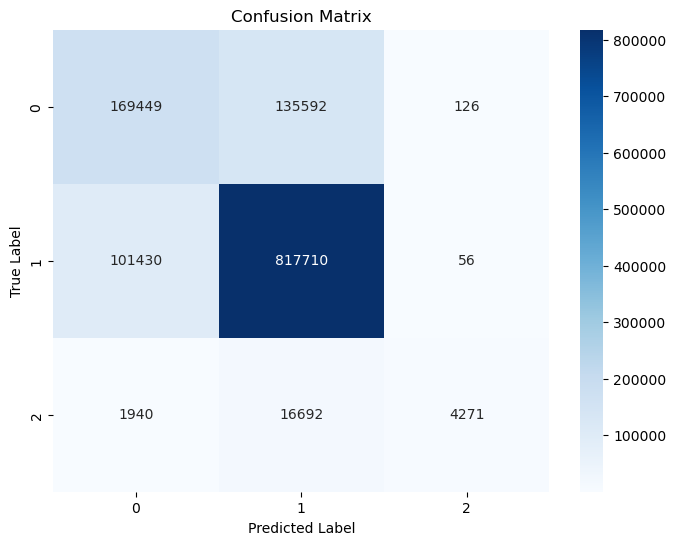

[[169449 135592    126]
 [101430 817710     56]
 [  1940  16692   4271]]
Evaluating with top 200 features:
              precision    recall  f1-score   support

           0       0.60      0.62      0.61    294422
           1       0.89      0.86      0.88    947830
           2       0.21      0.95      0.34      5014

    accuracy                           0.81   1247266
   macro avg       0.57      0.81      0.61   1247266
weighted avg       0.82      0.81      0.81   1247266



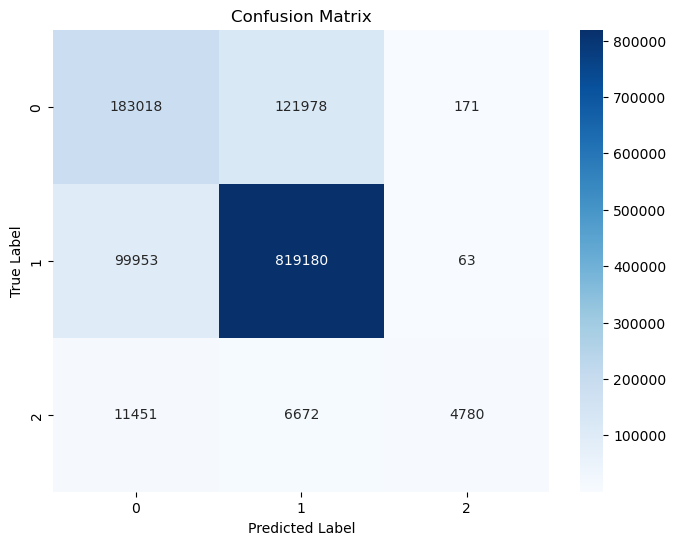

[[183018 121978    171]
 [ 99953 819180     63]
 [ 11451   6672   4780]]
Evaluating with top 175 features:
              precision    recall  f1-score   support

           0       0.65      0.62      0.63    316519
           1       0.88      0.88      0.88    926046
           2       0.20      0.96      0.33      4701

    accuracy                           0.81   1247266
   macro avg       0.58      0.82      0.61   1247266
weighted avg       0.82      0.81      0.82   1247266



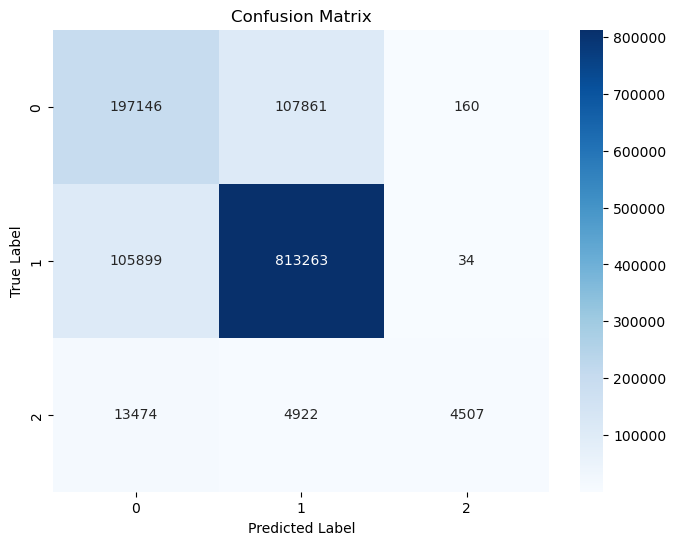

[[197146 107861    160]
 [105899 813263     34]
 [ 13474   4922   4507]]
Evaluating with top 150 features:
              precision    recall  f1-score   support

           0       0.62      0.61      0.61    309803
           1       0.88      0.87      0.88    932346
           2       0.21      0.96      0.35      5117

    accuracy                           0.81   1247266
   macro avg       0.57      0.81      0.61   1247266
weighted avg       0.81      0.81      0.81   1247266



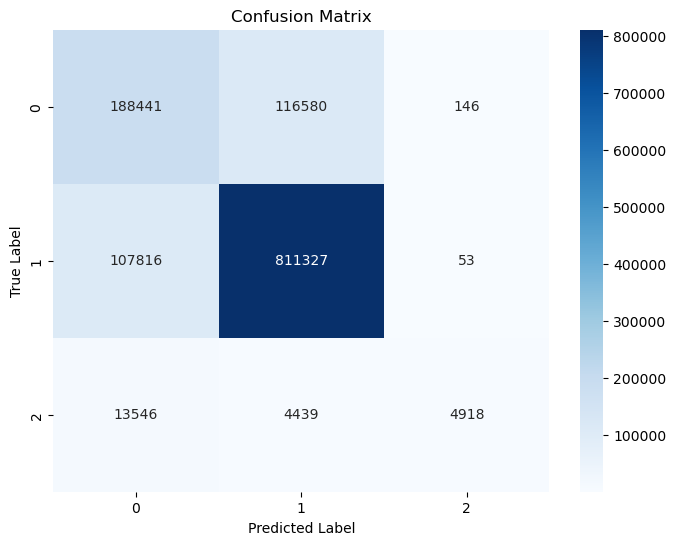

[[188441 116580    146]
 [107816 811327     53]
 [ 13546   4439   4918]]
Evaluating with top 125 features:
              precision    recall  f1-score   support

           0       0.57      0.62      0.60    283302
           1       0.89      0.85      0.87    959161
           2       0.20      0.95      0.33      4803

    accuracy                           0.80   1247266
   macro avg       0.55      0.81      0.60   1247266
weighted avg       0.82      0.80      0.81   1247266



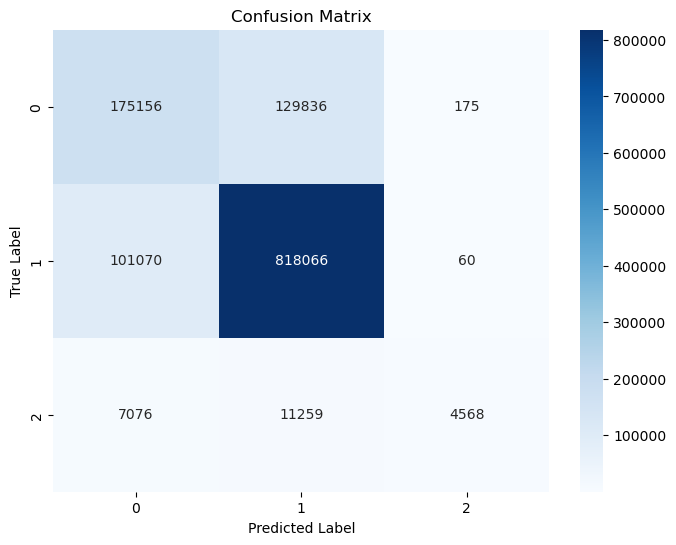

[[175156 129836    175]
 [101070 818066     60]
 [  7076  11259   4568]]
Evaluating with top 100 features:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63    291576
           1       0.90      0.87      0.88    949973
           2       0.24      0.96      0.38      5717

    accuracy                           0.82   1247266
   macro avg       0.58      0.83      0.63   1247266
weighted avg       0.83      0.82      0.82   1247266



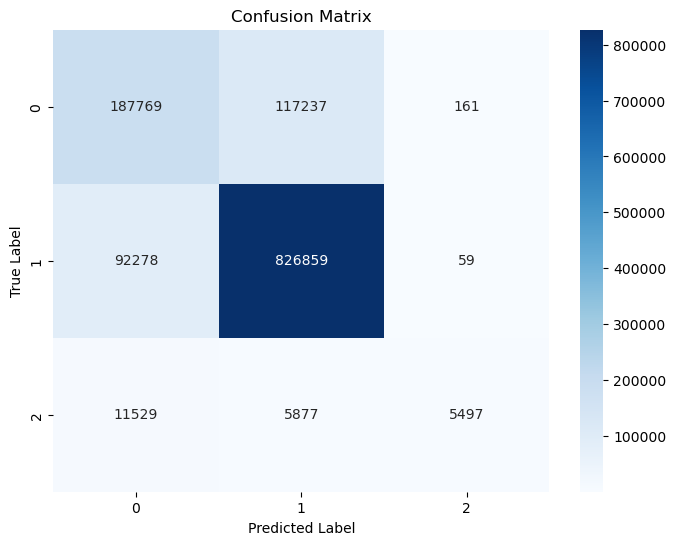

[[187769 117237    161]
 [ 92278 826859     59]
 [ 11529   5877   5497]]
Evaluating with top 75 features:
              precision    recall  f1-score   support

           0       0.47      0.61      0.53    239022
           1       0.90      0.82      0.86   1003230
           2       0.21      0.96      0.34      5014

    accuracy                           0.78   1247266
   macro avg       0.53      0.79      0.58   1247266
weighted avg       0.81      0.78      0.79   1247266



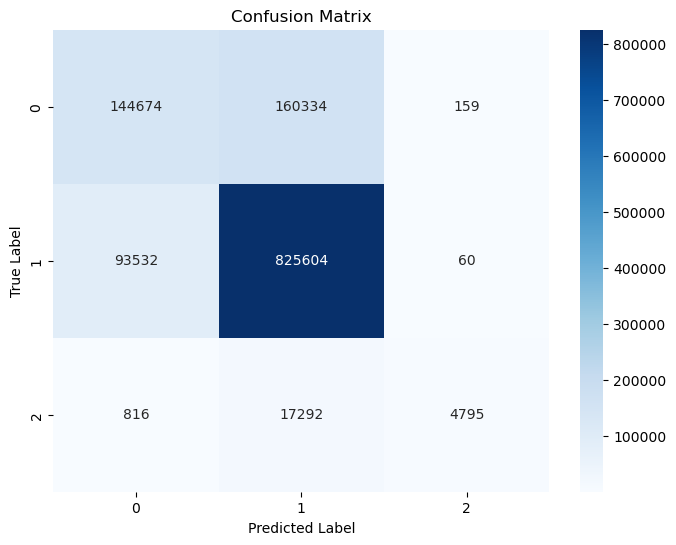

[[144674 160334    159]
 [ 93532 825604     60]
 [   816  17292   4795]]
Evaluating with top 50 features:
              precision    recall  f1-score   support

           0       0.59      0.60      0.60    297531
           1       0.89      0.86      0.87    945003
           2       0.20      0.96      0.33      4732

    accuracy                           0.80   1247266
   macro avg       0.56      0.81      0.60   1247266
weighted avg       0.81      0.80      0.81   1247266



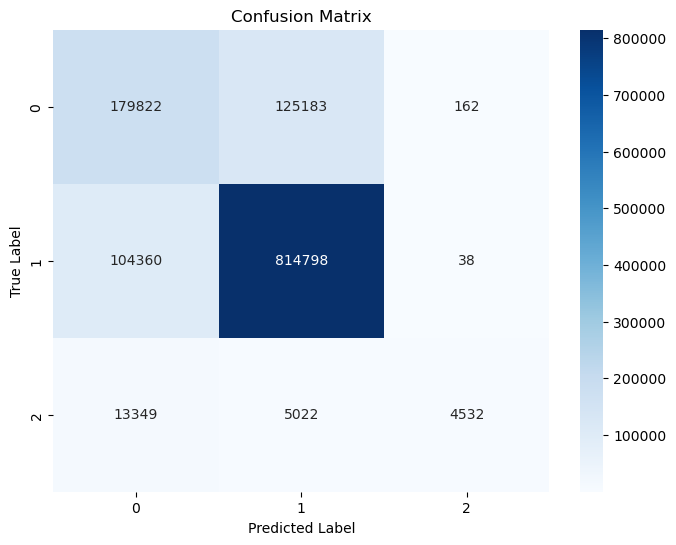

[[179822 125183    162]
 [104360 814798     38]
 [ 13349   5022   4532]]
Evaluating with top 40 features:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62    303915
           1       0.89      0.87      0.88    938698
           2       0.19      0.96      0.32      4653

    accuracy                           0.81   1247266
   macro avg       0.57      0.82      0.61   1247266
weighted avg       0.82      0.81      0.81   1247266



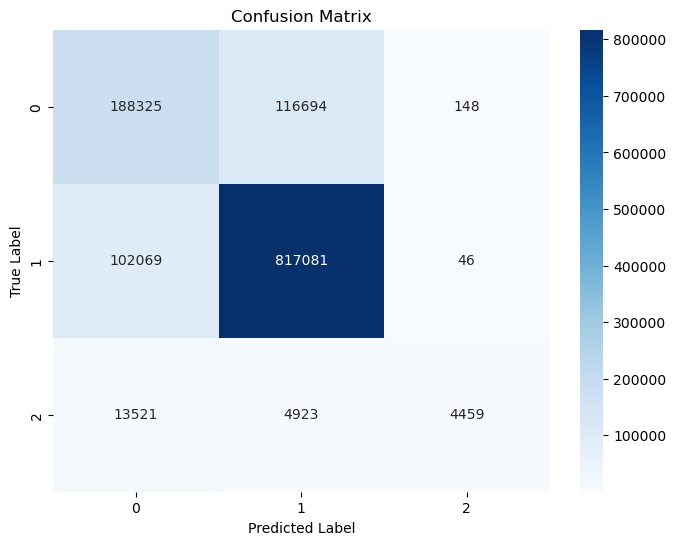

[[188325 116694    148]
 [102069 817081     46]
 [ 13521   4923   4459]]
Evaluating with top 30 features:
              precision    recall  f1-score   support

           0       0.60      0.59      0.60    306476
           1       0.88      0.86      0.87    935981
           2       0.20      0.95      0.33      4809

    accuracy                           0.80   1247266
   macro avg       0.56      0.80      0.60   1247266
weighted avg       0.81      0.80      0.80   1247266



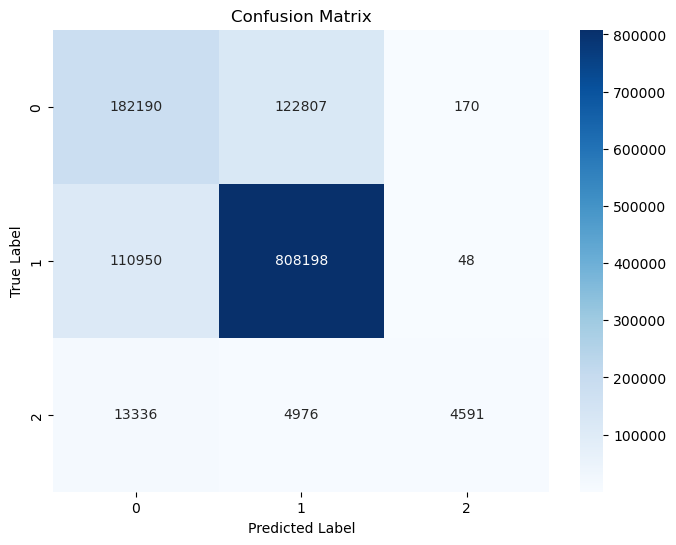

[[182190 122807    170]
 [110950 808198     48]
 [ 13336   4976   4591]]
Evaluating with top 25 features:
              precision    recall  f1-score   support

           0       0.63      0.61      0.62    316922
           1       0.88      0.87      0.88    925806
           2       0.19      0.95      0.32      4538

    accuracy                           0.81   1247266
   macro avg       0.57      0.81      0.60   1247266
weighted avg       0.81      0.81      0.81   1247266



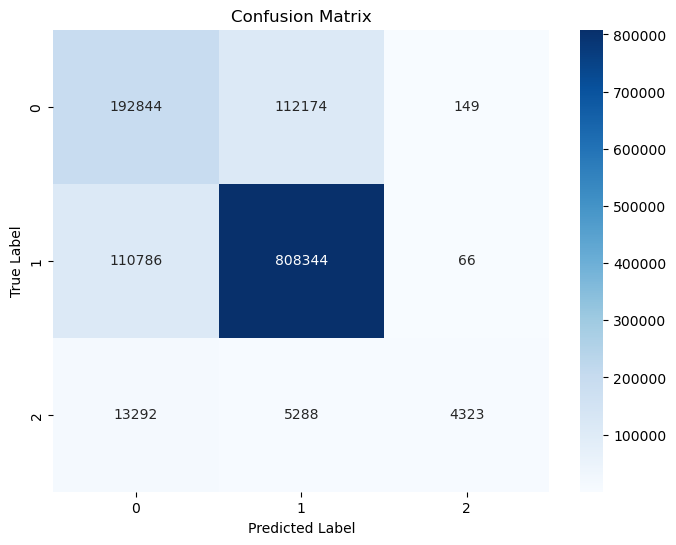

[[192844 112174    149]
 [110786 808344     66]
 [ 13292   5288   4323]]
Evaluating with top 20 features:
              precision    recall  f1-score   support

           0       0.70      0.62      0.66    347059
           1       0.87      0.89      0.88    895257
           2       0.20      0.95      0.34      4950

    accuracy                           0.82   1247266
   macro avg       0.59      0.82      0.63   1247266
weighted avg       0.82      0.82      0.82   1247266



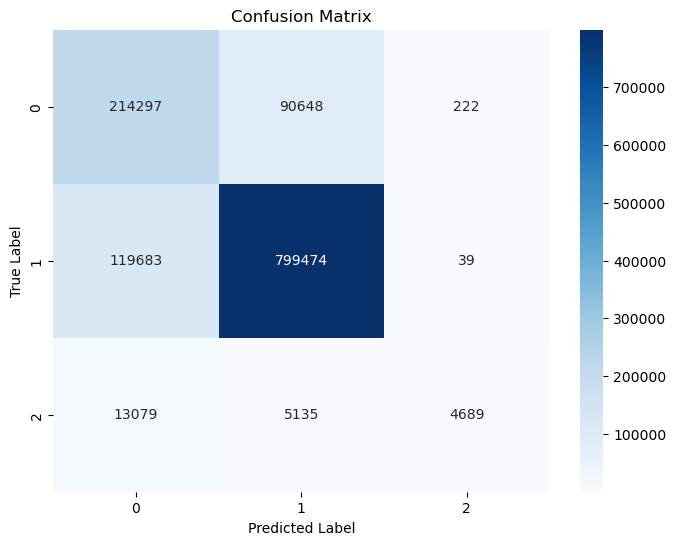

[[214297  90648    222]
 [119683 799474     39]
 [ 13079   5135   4689]]
Evaluating with top 15 features:
              precision    recall  f1-score   support

           0       0.53      0.58      0.55    279088
           1       0.87      0.83      0.85    963400
           2       0.20      0.96      0.33      4778

    accuracy                           0.78   1247266
   macro avg       0.53      0.79      0.58   1247266
weighted avg       0.79      0.78      0.78   1247266



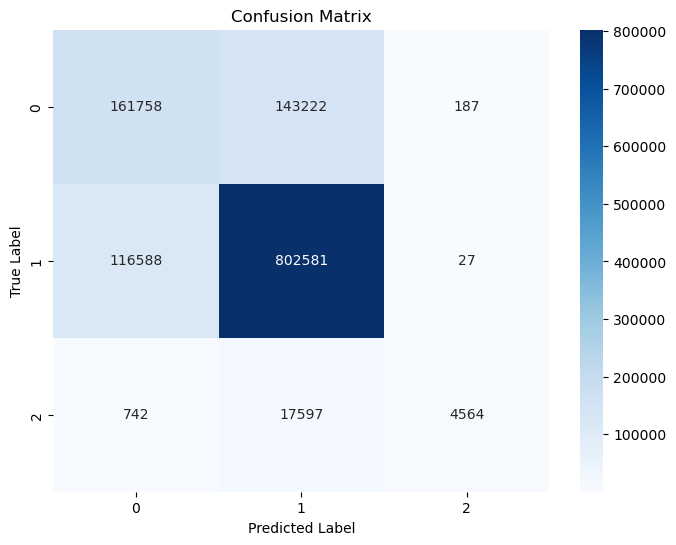

[[161758 143222    187]
 [116588 802581     27]
 [   742  17597   4564]]
Evaluating with top 10 features:
              precision    recall  f1-score   support

           0       0.62      0.55      0.58    348818
           1       0.84      0.86      0.85    893600
           2       0.20      0.96      0.34      4848

    accuracy                           0.77   1247266
   macro avg       0.55      0.79      0.59   1247266
weighted avg       0.77      0.77      0.77   1247266



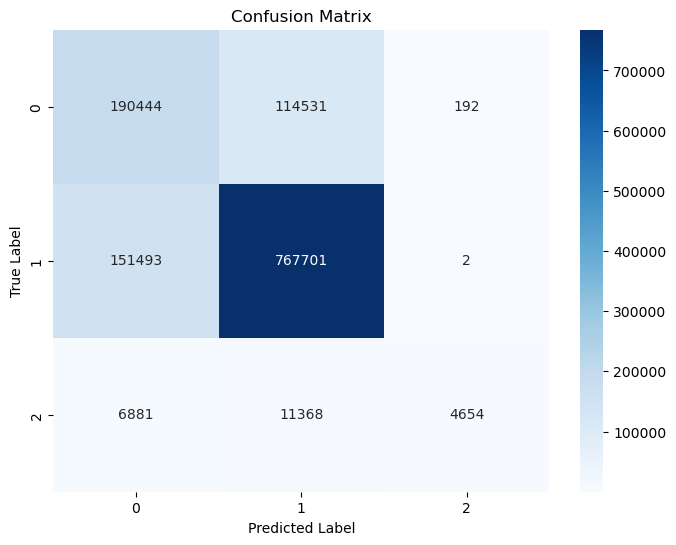

[[190444 114531    192]
 [151493 767701      2]
 [  6881  11368   4654]]


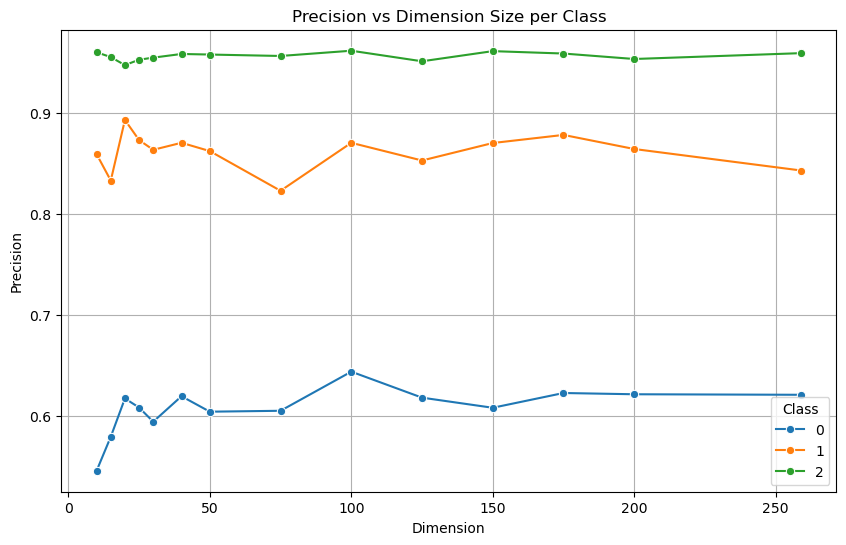

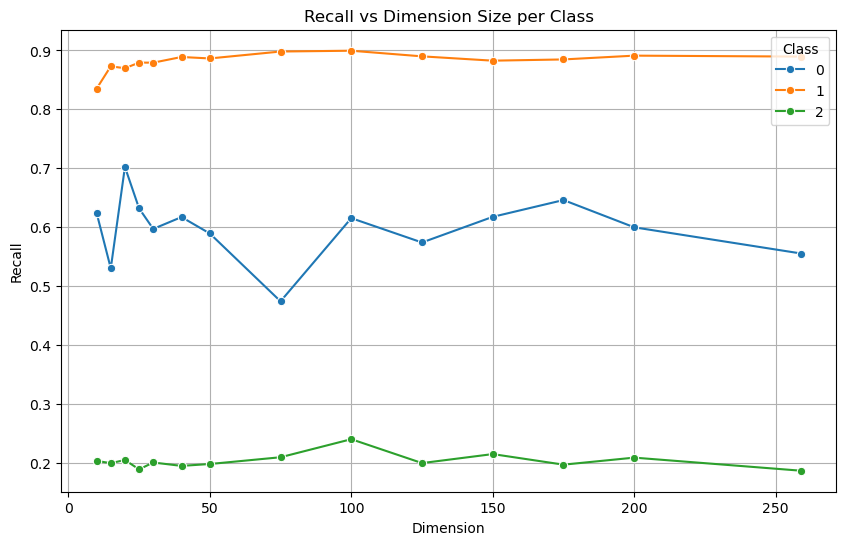

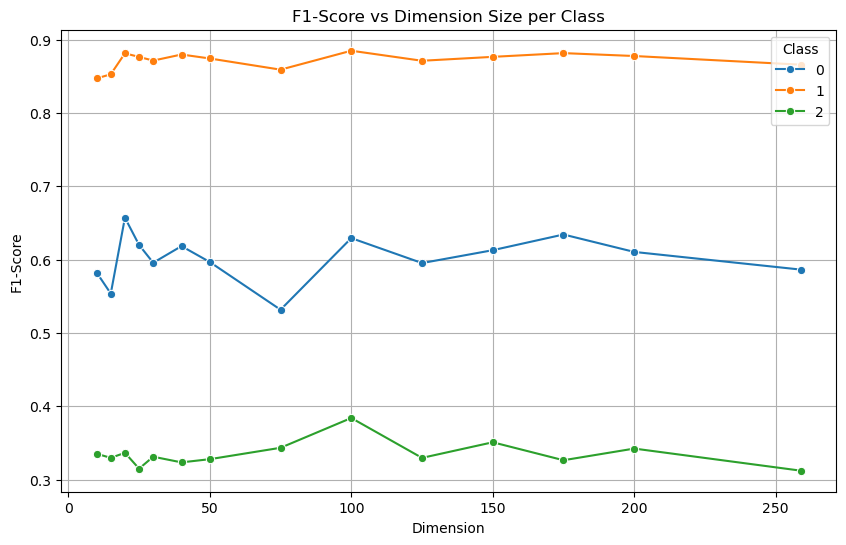

In [9]:
precision_list = []
recall_list = []
f1_list = []
x_col_size = [200, 175, 150, 125, 100, 75, 50, 40, 30, 25, 20, 15, 10]
lgbm = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, 
                          min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)
evaluate(lgbm, 259)


for len in x_col_size:
    print(f"Evaluating with top {len} features:")
    importances = lgbm.feature_importances_
    feature_importances = pd.DataFrame({'Feature': x_cols, 'Importance': importances})
    feature_importances = feature_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    top_features = feature_importances.head(len)
    top_feature_names = top_features['Feature'].tolist()
    x_cols = top_feature_names
    
    lgbm = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, 
                              min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)
    evaluate(lgbm, len)

df = pd.DataFrame(precision_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="Precision", hue="Class", marker="o")
plt.title("Precision vs Dimension Size per Class")
plt.grid(True)
plt.show()

df = pd.DataFrame(recall_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="Recall", hue="Class", marker="o")
plt.title("Recall vs Dimension Size per Class")
plt.grid(True)
plt.show()

df = pd.DataFrame(f1_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="F1-Score", hue="Class", marker="o")
plt.title("F1-Score vs Dimension Size per Class")
plt.grid(True)
plt.savefig('data/figures/dim-test.png', dpi=600, bbox_inches='tight')
plt.show()

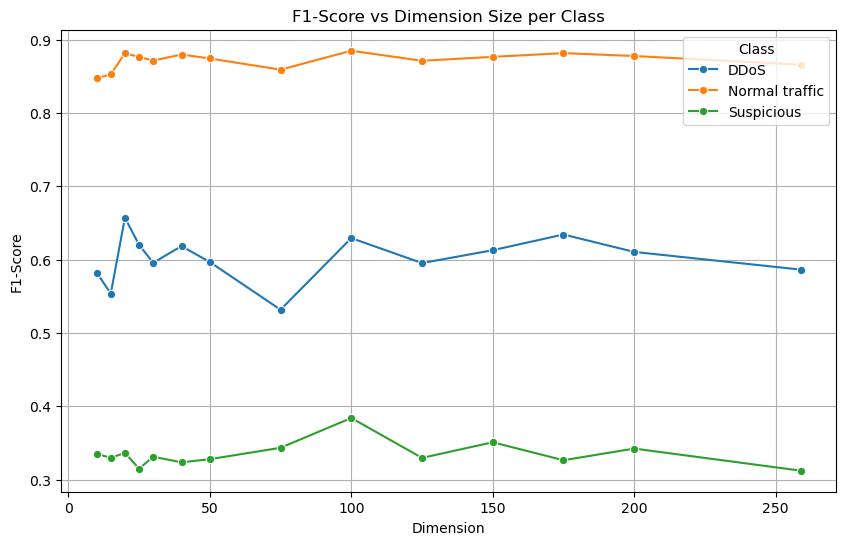

In [ ]:
df = pd.DataFrame(f1_list)
label_mapping = {
    '0': 'DDoS',
    '1': 'Normal traffic',
    '2': 'Suspicious'
}
df['Class'] = df['Class'].map(label_mapping)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="F1-Score", hue="Class", marker="o")
plt.grid(True)
plt.savefig('data/figures/dim-test.png', dpi=600, bbox_inches='tight')
plt.show()

              precision    recall  f1-score   support

           0       0.39      0.64      0.48    184462
           1       0.93      0.81      0.86   1057737
           2       0.21      0.96      0.35      5067

    accuracy                           0.78   1247266
   macro avg       0.51      0.80      0.56   1247266
weighted avg       0.85      0.78      0.80   1247266



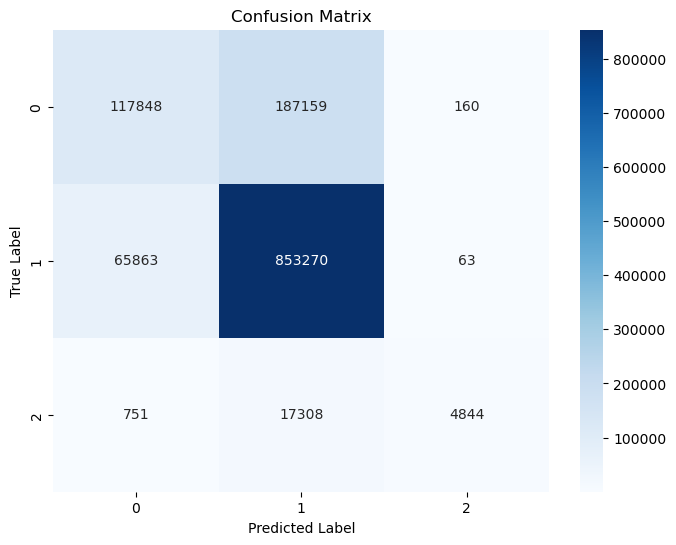

[[117848 187159    160]
 [ 65863 853270     63]
 [   751  17308   4844]]
Evaluating with top 200 features:
              precision    recall  f1-score   support

           0       0.48      0.66      0.56    223443
           1       0.92      0.83      0.87   1018982
           2       0.20      0.96      0.33      4841

    accuracy                           0.80   1247266
   macro avg       0.53      0.82      0.59   1247266
weighted avg       0.84      0.80      0.81   1247266



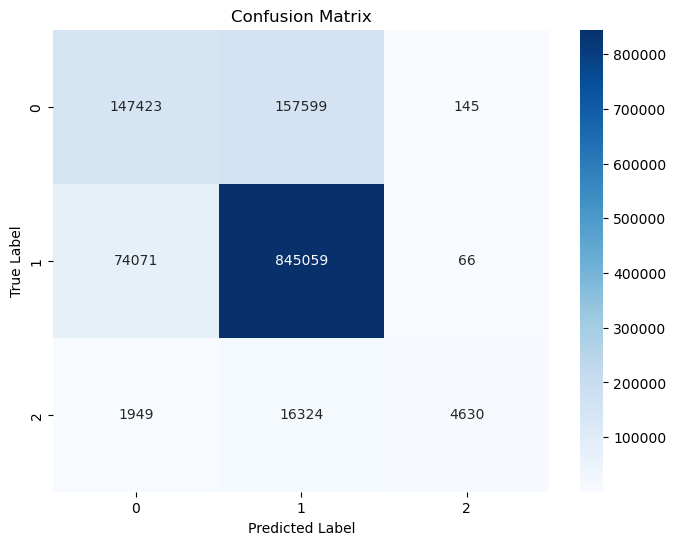

[[147423 157599    145]
 [ 74071 845059     66]
 [  1949  16324   4630]]
Evaluating with top 175 features:
              precision    recall  f1-score   support

           0       0.54      0.62      0.58    263417
           1       0.91      0.85      0.88    979063
           2       0.20      0.96      0.33      4786

    accuracy                           0.80   1247266
   macro avg       0.55      0.81      0.60   1247266
weighted avg       0.83      0.80      0.81   1247266



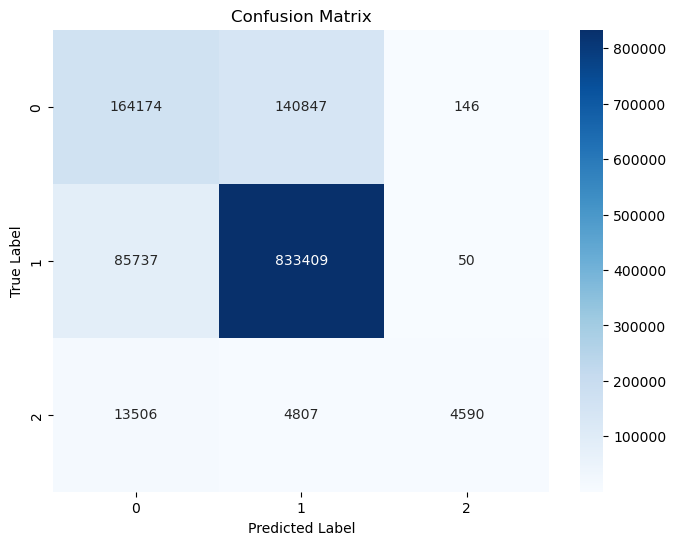

[[164174 140847    146]
 [ 85737 833409     50]
 [ 13506   4807   4590]]
Evaluating with top 150 features:
              precision    recall  f1-score   support

           0       0.40      0.64      0.49    191323
           1       0.93      0.81      0.86   1050740
           2       0.22      0.96      0.36      5203

    accuracy                           0.78   1247266
   macro avg       0.52      0.80      0.57   1247266
weighted avg       0.84      0.78      0.81   1247266



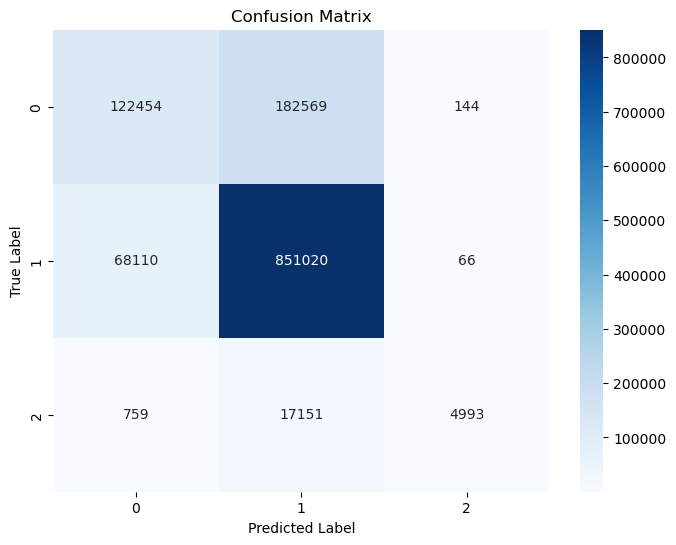

[[122454 182569    144]
 [ 68110 851020     66]
 [   759  17151   4993]]
Evaluating with top 125 features:
              precision    recall  f1-score   support

           0       0.51      0.65      0.57    241024
           1       0.92      0.85      0.88   1001256
           2       0.21      0.96      0.34      4986

    accuracy                           0.81   1247266
   macro avg       0.55      0.82      0.60   1247266
weighted avg       0.84      0.81      0.82   1247266



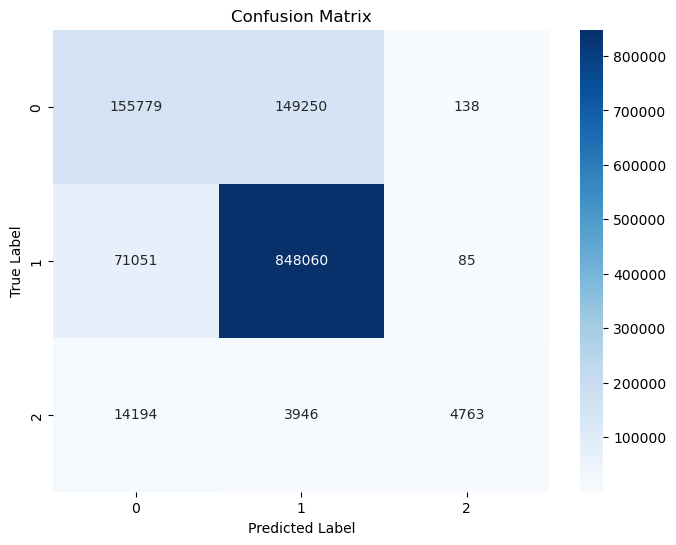

[[155779 149250    138]
 [ 71051 848060     85]
 [ 14194   3946   4763]]
Evaluating with top 100 features:
              precision    recall  f1-score   support

           0       0.44      0.66      0.53    203292
           1       0.93      0.82      0.87   1039260
           2       0.20      0.96      0.33      4714

    accuracy                           0.79   1247266
   macro avg       0.52      0.81      0.58   1247266
weighted avg       0.85      0.79      0.81   1247266



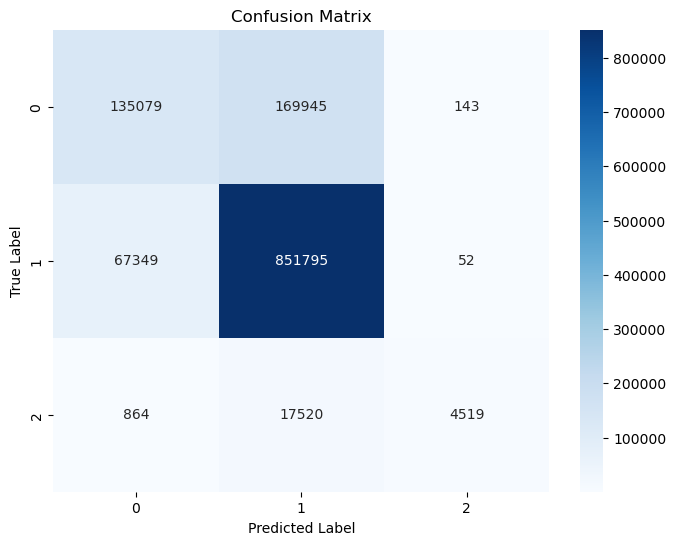

[[135079 169945    143]
 [ 67349 851795     52]
 [   864  17520   4519]]
Evaluating with top 75 features:
              precision    recall  f1-score   support

           0       0.50      0.68      0.57    223230
           1       0.92      0.83      0.88   1018776
           2       0.22      0.96      0.36      5260

    accuracy                           0.81   1247266
   macro avg       0.55      0.82      0.60   1247266
weighted avg       0.84      0.81      0.82   1247266



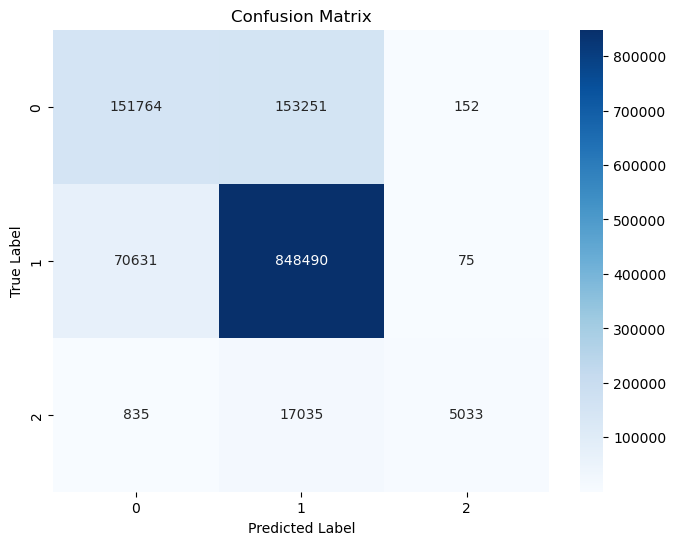

[[151764 153251    152]
 [ 70631 848490     75]
 [   835  17035   5033]]
Evaluating with top 50 features:
              precision    recall  f1-score   support

           0       0.51      0.66      0.58    239774
           1       0.92      0.84      0.88   1002502
           2       0.21      0.96      0.34      4990

    accuracy                           0.81   1247266
   macro avg       0.55      0.82      0.60   1247266
weighted avg       0.84      0.81      0.82   1247266



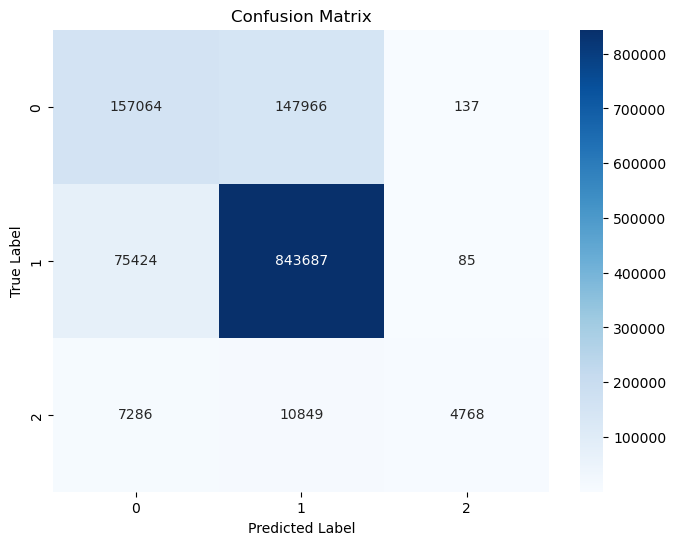

[[157064 147966    137]
 [ 75424 843687     85]
 [  7286  10849   4768]]
Evaluating with top 40 features:
              precision    recall  f1-score   support

           0       0.50      0.66      0.57    232188
           1       0.92      0.84      0.88   1010093
           2       0.21      0.96      0.34      4985

    accuracy                           0.81   1247266
   macro avg       0.54      0.82      0.60   1247266
weighted avg       0.84      0.81      0.82   1247266



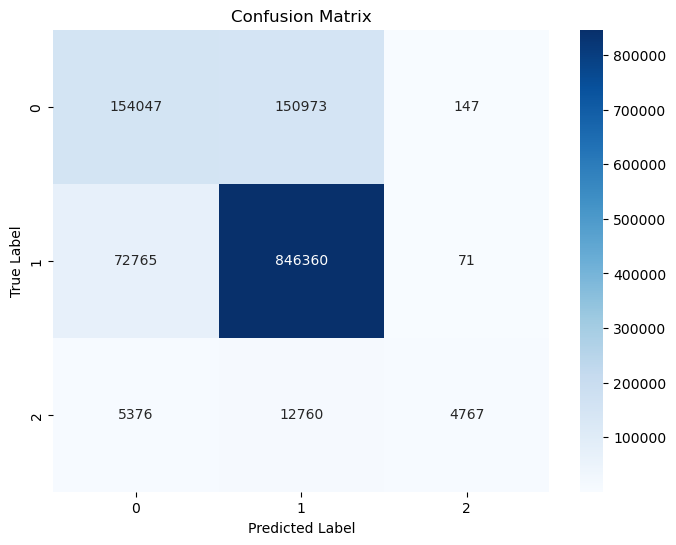

[[154047 150973    147]
 [ 72765 846360     71]
 [  5376  12760   4767]]
Evaluating with top 30 features:
              precision    recall  f1-score   support

           0       0.63      0.61      0.62    316640
           1       0.88      0.87      0.88    925013
           2       0.22      0.90      0.35      5613

    accuracy                           0.81   1247266
   macro avg       0.58      0.79      0.62   1247266
weighted avg       0.81      0.81      0.81   1247266



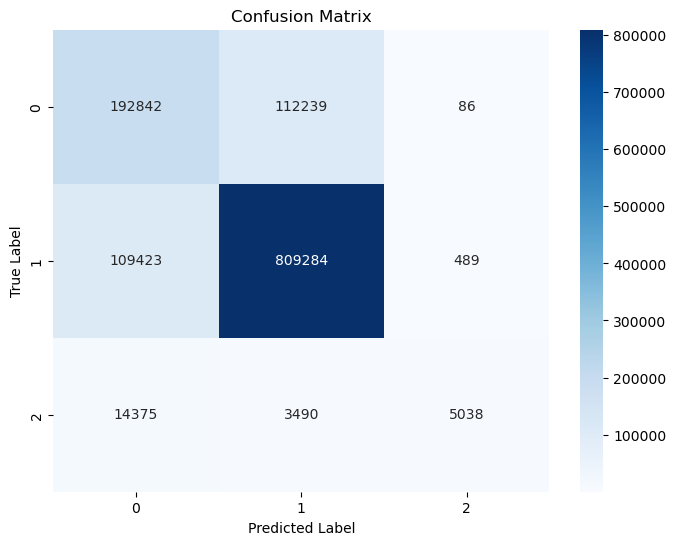

[[192842 112239     86]
 [109423 809284    489]
 [ 14375   3490   5038]]
Evaluating with top 25 features:
              precision    recall  f1-score   support

           0       0.50      0.65      0.57    235349
           1       0.92      0.84      0.88   1006833
           2       0.21      0.95      0.35      5084

    accuracy                           0.80   1247266
   macro avg       0.54      0.81      0.60   1247266
weighted avg       0.84      0.80      0.82   1247266



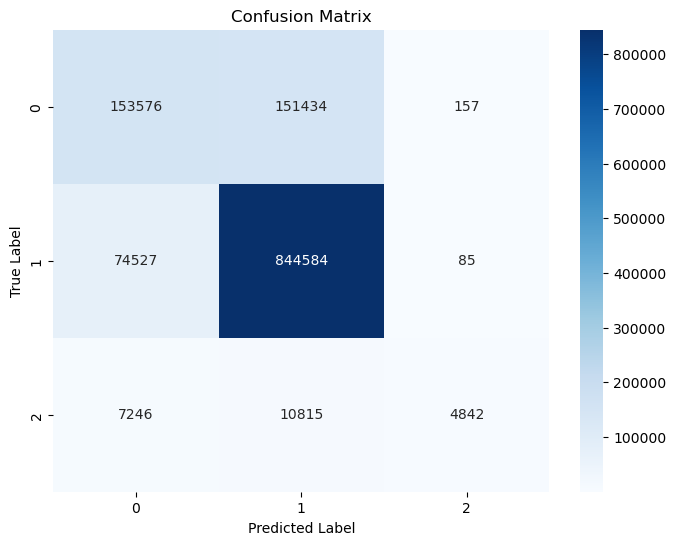

[[153576 151434    157]
 [ 74527 844584     85]
 [  7246  10815   4842]]
Evaluating with top 20 features:
              precision    recall  f1-score   support

           0       0.53      0.62      0.57    261185
           1       0.91      0.85      0.88    981137
           2       0.21      0.97      0.34      4944

    accuracy                           0.80   1247266
   macro avg       0.55      0.81      0.60   1247266
weighted avg       0.82      0.80      0.81   1247266



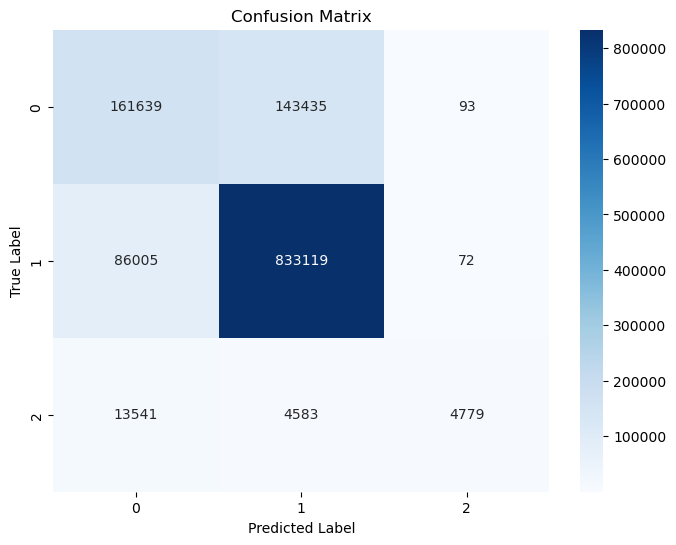

[[161639 143435     93]
 [ 86005 833119     72]
 [ 13541   4583   4779]]
Evaluating with top 15 features:
              precision    recall  f1-score   support

           0       0.53      0.62      0.57    262906
           1       0.91      0.85      0.88    979307
           2       0.20      0.92      0.33      5053

    accuracy                           0.80   1247266
   macro avg       0.55      0.80      0.59   1247266
weighted avg       0.82      0.80      0.81   1247266



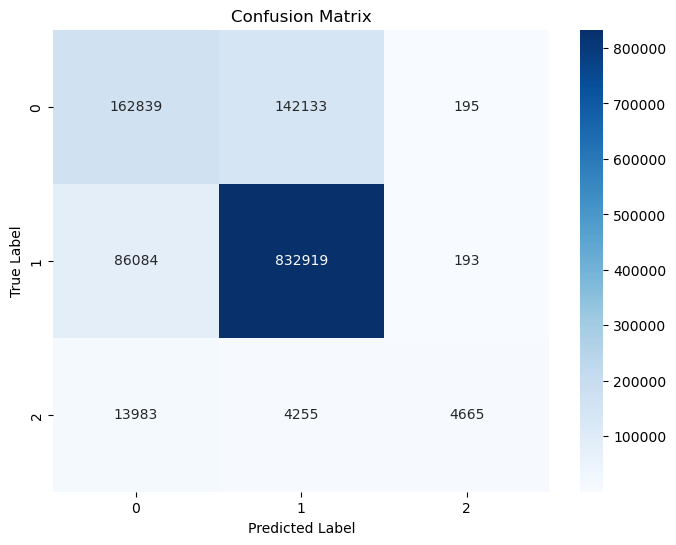

[[162839 142133    195]
 [ 86084 832919    193]
 [ 13983   4255   4665]]
Evaluating with top 10 features:
              precision    recall  f1-score   support

           0       0.41      0.64      0.50    197278
           1       0.92      0.81      0.86   1045135
           2       0.20      0.96      0.34      4853

    accuracy                           0.79   1247266
   macro avg       0.51      0.80      0.57   1247266
weighted avg       0.84      0.79      0.81   1247266



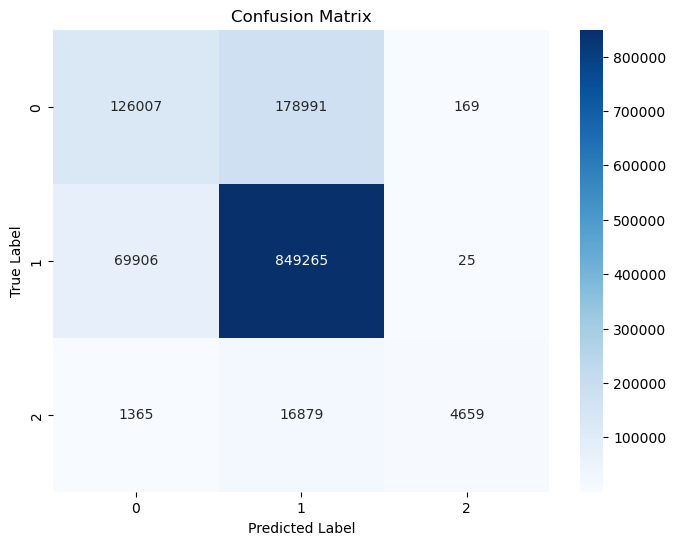

[[126007 178991    169]
 [ 69906 849265     25]
 [  1365  16879   4659]]


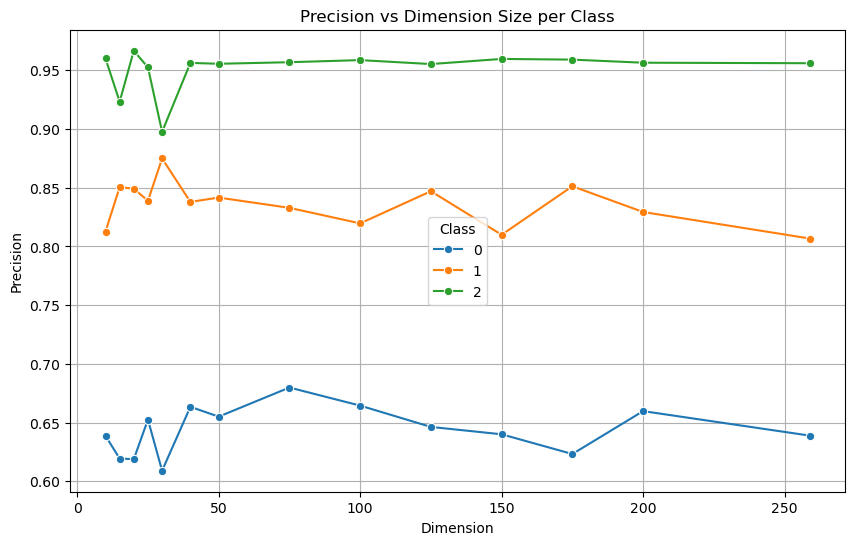

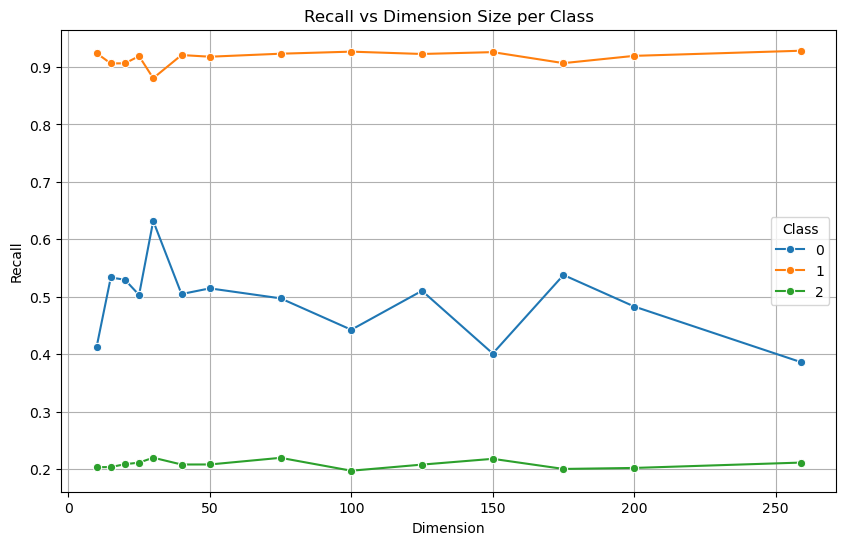

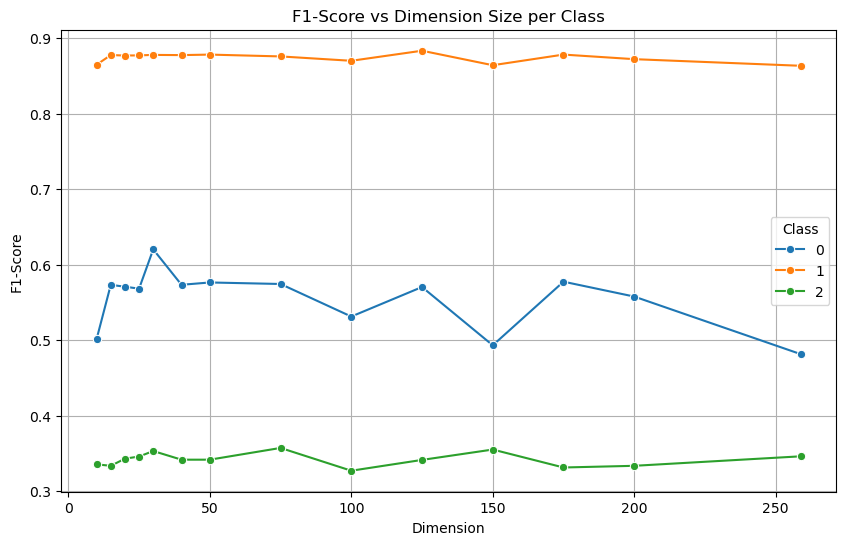

In [73]:
precision_list = []
recall_list = []
f1_list = []
x_col_size = [200, 175, 150, 125, 100, 75, 50, 40, 30, 25, 20, 15, 10]
lgbm = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, 
                          min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)
evaluate(lgbm, 259)


for len in x_col_size:
    print(f"Evaluating with top {len} features:")
    importances = lgbm.feature_importances_
    feature_importances = pd.DataFrame({'Feature': x_cols, 'Importance': importances})
    feature_importances = feature_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    top_features = feature_importances.head(len)
    top_feature_names = top_features['Feature'].tolist()
    x_cols = top_feature_names
    
    lgbm = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, 
                          min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)
    evaluate(lgbm, len)

df = pd.DataFrame(precision_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="Precision", hue="Class", marker="o")
plt.title("Precision vs Dimension Size per Class")
plt.grid(True)
plt.show()

df = pd.DataFrame(recall_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="Recall", hue="Class", marker="o")
plt.title("Recall vs Dimension Size per Class")
plt.grid(True)
plt.show()

df = pd.DataFrame(f1_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="F1-Score", hue="Class", marker="o")
plt.title("F1-Score vs Dimension Size per Class")
plt.grid(True)
plt.show()

In [74]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'cluster', 'cluster112', 'dist_centroid_0',
          'dist_centroid_1', 'dist_centroid_2', 'dist_centroid_3', 'dist_centroid_4',
          'dist_centroid_5', 'dist_centroid_6', 'dist_centroid_7', 'dist_centroid_8',
          'dist_centroid_9', 'dist_centroid_10', 'dist_centroid_11', 'dist_centroid_12',
          'dist_centroid_13', 'dist_centroid_14', 'dist_centroid_15', 'dist_centroid_16','dist_centroid_17',
          'dist_centroid_silhouette_1', 'dist_centroid_silhouette_2', 'dist_centroid_silhouette_3',
          'dist_centroid_silhouette_4', 'dist_centroid_silhouette_5', 'dist_centroid_silhouette_6',
          'dist_centroid_silhouette_7','dist_centroid_silhouette_8','dist_centroid_silhouette_9',
          'dist_centroid_silhouette_10','dist_centroid_silhouette_11','dist_centroid_silhouette_12',
          'dist_centroid_silhouette_13','dist_centroid_silhouette_14','dist_centroid_silhouette_15',
          'dist_centroid_silhouette_16','dist_centroid_silhouette_17','dist_centroid_silhouette_18',
          'dist_centroid_silhouette_19','dist_centroid_silhouette_20','dist_centroid_silhouette_21',
          'dist_centroid_silhouette_22','dist_centroid_silhouette_23','dist_centroid_silhouette_24',
          'dist_centroid_silhouette_25','dist_centroid_silhouette_26','dist_centroid_silhouette_27',
          'dist_centroid_silhouette_28','dist_centroid_silhouette_29','dist_centroid_silhouette_30',
          'dist_centroid_silhouette_31','dist_centroid_silhouette_32','dist_centroid_silhouette_33',
          'dist_centroid_silhouette_34','dist_centroid_silhouette_35','dist_centroid_silhouette_36',
          'dist_centroid_silhouette_37','dist_centroid_silhouette_38','dist_centroid_silhouette_39',
          'dist_centroid_silhouette_40','dist_centroid_silhouette_41','dist_centroid_silhouette_42',
          'dist_centroid_silhouette_43','dist_centroid_silhouette_44','dist_centroid_silhouette_45',
          'dist_centroid_silhouette_46','dist_centroid_silhouette_47','dist_centroid_silhouette_48',
          'dist_centroid_silhouette_49','dist_centroid_silhouette_50','dist_centroid_silhouette_51',
          'dist_centroid_silhouette_52','dist_centroid_silhouette_53','dist_centroid_silhouette_54',
 'dist_centroid_silhouette_55',
 'dist_centroid_silhouette_56',
 'dist_centroid_silhouette_57',
 'dist_centroid_silhouette_58',
 'dist_centroid_silhouette_59',
 'dist_centroid_silhouette_60',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_62',
 'dist_centroid_silhouette_63',
 'dist_centroid_silhouette_64',
 'dist_centroid_silhouette_65',
 'dist_centroid_silhouette_66',
 'dist_centroid_silhouette_67',
 'dist_centroid_silhouette_68',
 'dist_centroid_silhouette_69',
 'dist_centroid_silhouette_70',
 'dist_centroid_silhouette_71',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_73',
 'dist_centroid_silhouette_74',
 'dist_centroid_silhouette_75',
 'dist_centroid_silhouette_76',
 'dist_centroid_silhouette_77',
 'dist_centroid_silhouette_78',
 'dist_centroid_silhouette_79',
 'dist_centroid_silhouette_80',
 'dist_centroid_silhouette_81',
 'dist_centroid_silhouette_82',
 'dist_centroid_silhouette_83',
 'dist_centroid_silhouette_84',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_86',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_88',
 'dist_centroid_silhouette_89',
 'dist_centroid_silhouette_90',
 'dist_centroid_silhouette_91',
 'dist_centroid_silhouette_92',
 'dist_centroid_silhouette_93',
 'dist_centroid_silhouette_94',
 'dist_centroid_silhouette_95',
 'dist_centroid_silhouette_96',
 'dist_centroid_silhouette_97',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_99',
 'dist_centroid_silhouette_100',
 'dist_centroid_silhouette_101',
 'dist_centroid_silhouette_102',
 'dist_centroid_silhouette_103',
 'dist_centroid_silhouette_104',
 'dist_centroid_silhouette_105',
 'dist_centroid_silhouette_106',
 'dist_centroid_silhouette_107',
 'dist_centroid_silhouette_108',
 'dist_centroid_silhouette_109',
 'dist_centroid_silhouette_110',
 'dist_centroid_silhouette_111', 'dbscan_cluster', 'tsne_1','tsne_2', 'umap_1', 'umap_2']

              precision    recall  f1-score   support

           0       0.26      0.65      0.37    122399
           1       0.95      0.78      0.86   1120320
           2       0.19      0.98      0.32      4547

    accuracy                           0.77   1247266
   macro avg       0.47      0.80      0.52   1247266
weighted avg       0.88      0.77      0.81   1247266



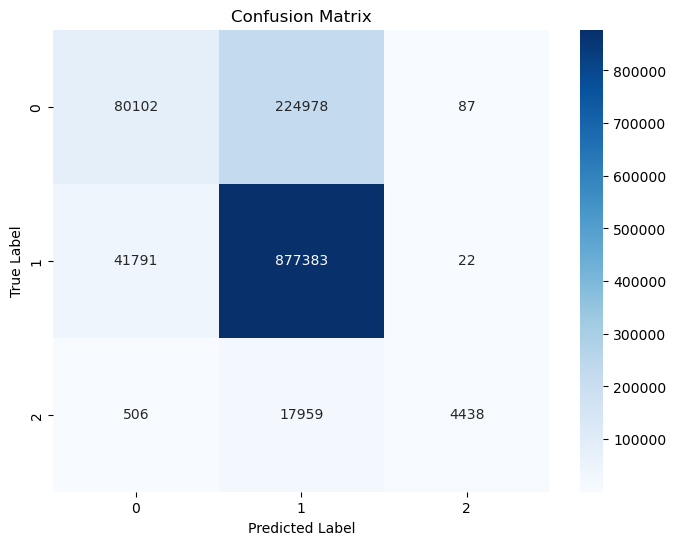

[[ 80102 224978     87]
 [ 41791 877383     22]
 [   506  17959   4438]]
Evaluating with top 200 features:
              precision    recall  f1-score   support

           0       0.21      0.68      0.32     92672
           1       0.97      0.77      0.86   1150115
           2       0.19      0.97      0.32      4479

    accuracy                           0.77   1247266
   macro avg       0.46      0.81      0.50   1247266
weighted avg       0.91      0.77      0.82   1247266



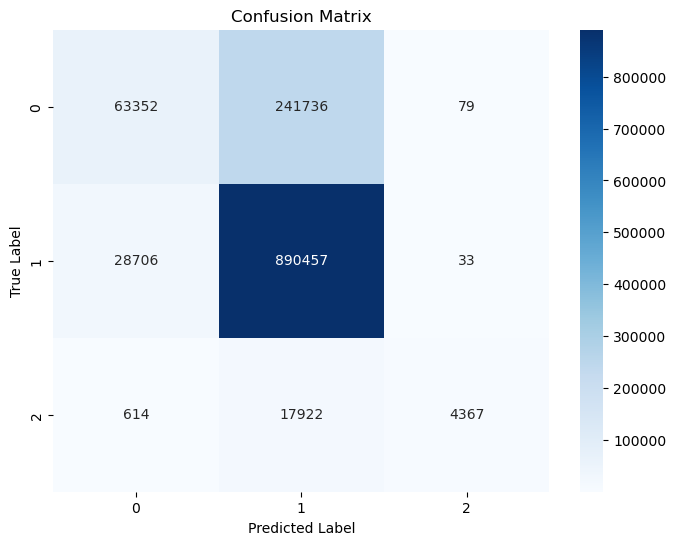

[[ 63352 241736     79]
 [ 28706 890457     33]
 [   614  17922   4367]]
Evaluating with top 175 features:
              precision    recall  f1-score   support

           0       0.23      0.66      0.34    108606
           1       0.96      0.78      0.86   1134568
           2       0.18      0.98      0.30      4092

    accuracy                           0.77   1247266
   macro avg       0.46      0.80      0.50   1247266
weighted avg       0.89      0.77      0.81   1247266



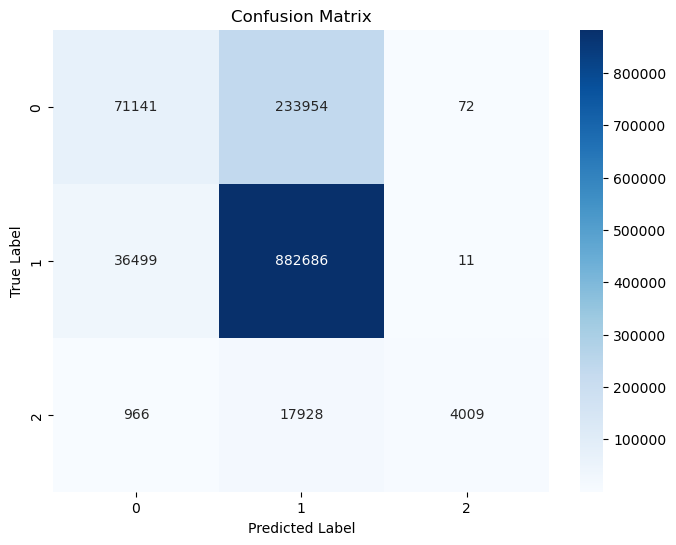

[[ 71141 233954     72]
 [ 36499 882686     11]
 [   966  17928   4009]]
Evaluating with top 150 features:
              precision    recall  f1-score   support

           0       0.24      0.62      0.35    119625
           1       0.95      0.78      0.86   1123272
           2       0.19      0.97      0.31      4369

    accuracy                           0.76   1247266
   macro avg       0.46      0.79      0.51   1247266
weighted avg       0.88      0.76      0.81   1247266



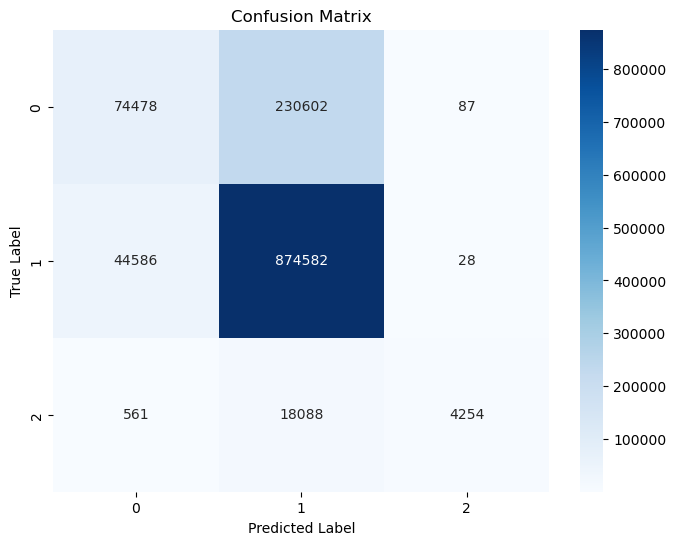

[[ 74478 230602     87]
 [ 44586 874582     28]
 [   561  18088   4254]]
Evaluating with top 125 features:
              precision    recall  f1-score   support

           0       0.19      0.69      0.30     85533
           1       0.97      0.77      0.86   1157563
           2       0.18      0.98      0.30      4170

    accuracy                           0.77   1247266
   macro avg       0.45      0.81      0.49   1247266
weighted avg       0.92      0.77      0.82   1247266



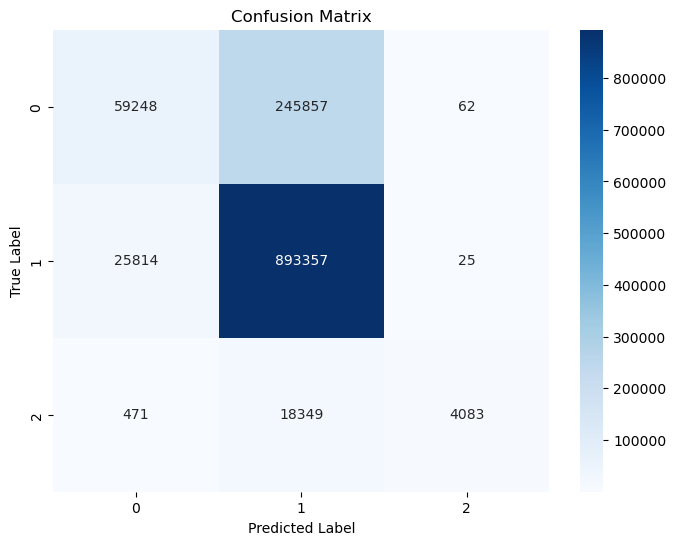

[[ 59248 245857     62]
 [ 25814 893357     25]
 [   471  18349   4083]]
Evaluating with top 100 features:
              precision    recall  f1-score   support

           0       0.21      0.66      0.32     96658
           1       0.97      0.77      0.86   1146122
           2       0.19      0.98      0.32      4486

    accuracy                           0.77   1247266
   macro avg       0.46      0.81      0.50   1247266
weighted avg       0.90      0.77      0.82   1247266



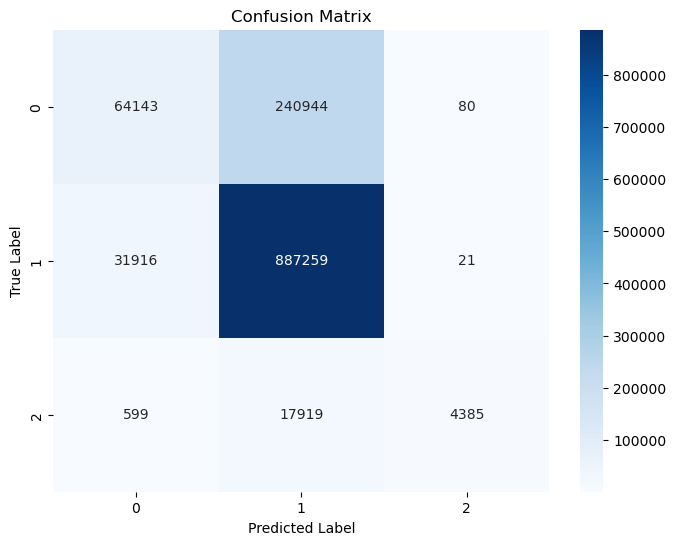

[[ 64143 240944     80]
 [ 31916 887259     21]
 [   599  17919   4385]]
Evaluating with top 75 features:
              precision    recall  f1-score   support

           0       0.21      0.70      0.32     92277
           1       0.97      0.78      0.86   1150447
           2       0.19      0.97      0.32      4542

    accuracy                           0.77   1247266
   macro avg       0.46      0.81      0.50   1247266
weighted avg       0.91      0.77      0.82   1247266



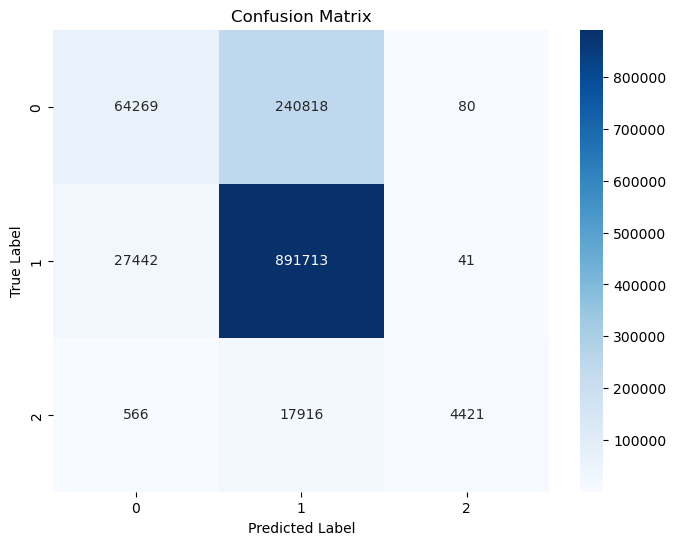

[[ 64269 240818     80]
 [ 27442 891713     41]
 [   566  17916   4421]]
Evaluating with top 50 features:
              precision    recall  f1-score   support

           0       0.21      0.63      0.32    102480
           1       0.96      0.77      0.86   1140792
           2       0.17      0.98      0.29      3994

    accuracy                           0.76   1247266
   macro avg       0.45      0.79      0.49   1247266
weighted avg       0.90      0.76      0.81   1247266



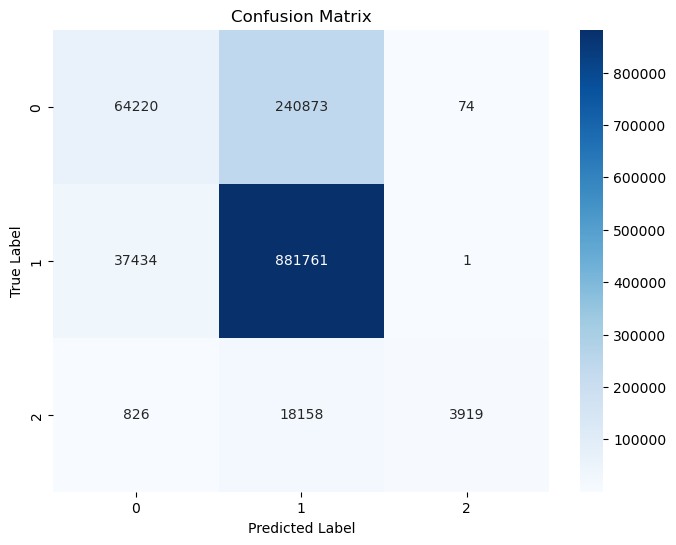

[[ 64220 240873     74]
 [ 37434 881761      1]
 [   826  18158   3919]]
Evaluating with top 40 features:
              precision    recall  f1-score   support

           0       0.25      0.65      0.36    115382
           1       0.96      0.78      0.86   1127403
           2       0.19      0.97      0.32      4481

    accuracy                           0.77   1247266
   macro avg       0.46      0.80      0.51   1247266
weighted avg       0.89      0.77      0.81   1247266



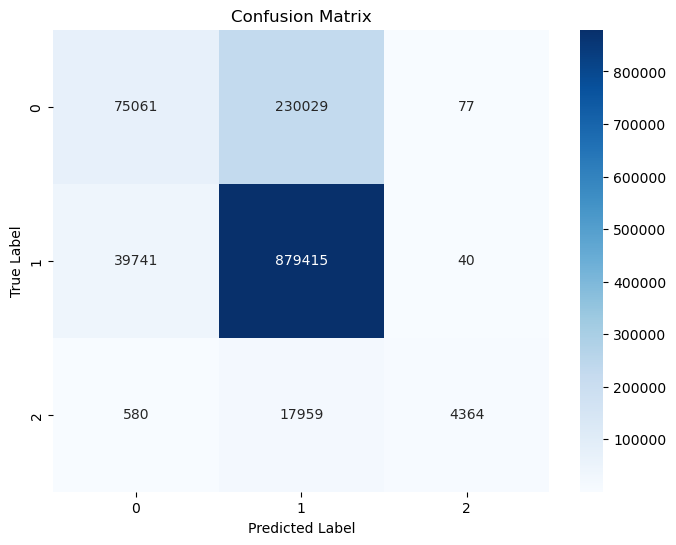

[[ 75061 230029     77]
 [ 39741 879415     40]
 [   580  17959   4364]]
Evaluating with top 30 features:
              precision    recall  f1-score   support

           0       0.18      0.64      0.28     86037
           1       0.97      0.77      0.86   1157363
           2       0.17      0.99      0.28      3866

    accuracy                           0.76   1247266
   macro avg       0.44      0.80      0.47   1247266
weighted avg       0.91      0.76      0.81   1247266



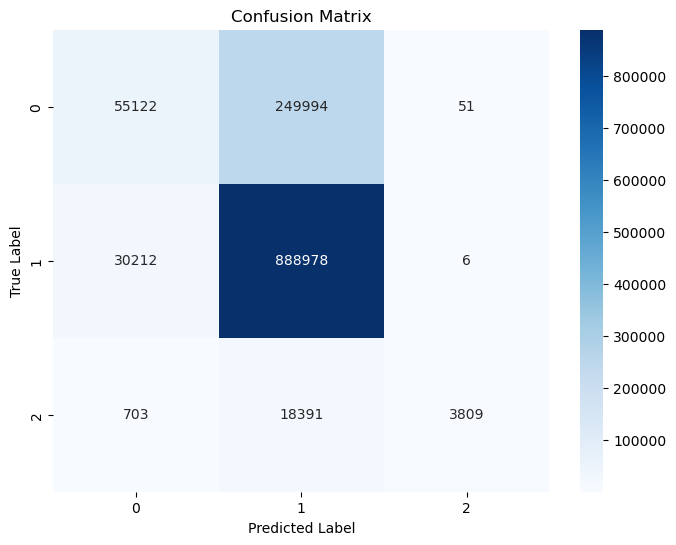

[[ 55122 249994     51]
 [ 30212 888978      6]
 [   703  18391   3809]]
Evaluating with top 25 features:
              precision    recall  f1-score   support

           0       0.19      0.68      0.30     86189
           1       0.97      0.77      0.86   1156783
           2       0.18      0.97      0.31      4294

    accuracy                           0.77   1247266
   macro avg       0.45      0.81      0.49   1247266
weighted avg       0.91      0.77      0.82   1247266



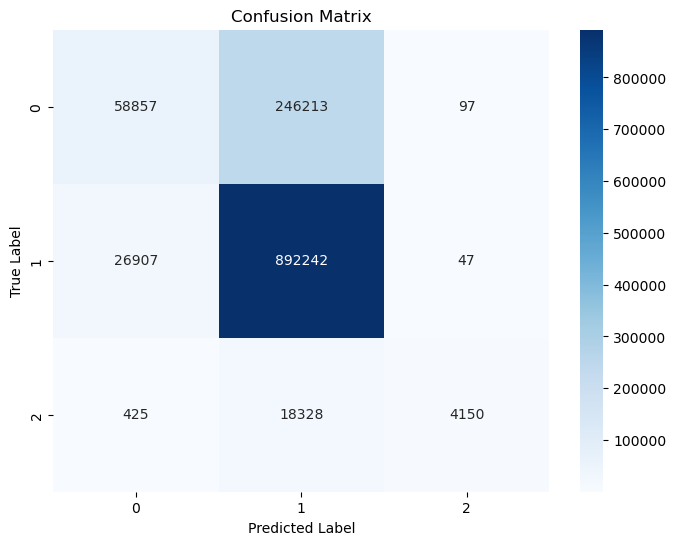

[[ 58857 246213     97]
 [ 26907 892242     47]
 [   425  18328   4150]]
Evaluating with top 20 features:
              precision    recall  f1-score   support

           0       0.34      0.66      0.45    156488
           1       0.94      0.80      0.86   1086898
           2       0.16      0.97      0.28      3880

    accuracy                           0.78   1247266
   macro avg       0.48      0.81      0.53   1247266
weighted avg       0.86      0.78      0.81   1247266



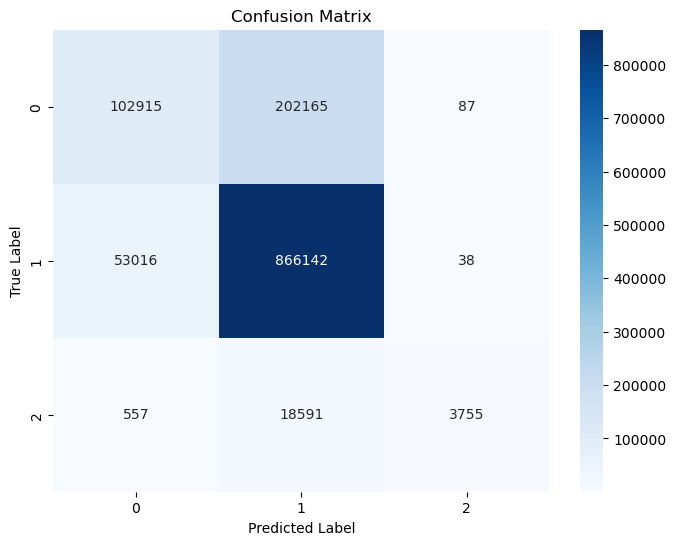

[[102915 202165     87]
 [ 53016 866142     38]
 [   557  18591   3755]]
Evaluating with top 15 features:
              precision    recall  f1-score   support

           0       0.27      0.65      0.38    126351
           1       0.95      0.78      0.86   1118432
           2       0.11      0.98      0.19      2483

    accuracy                           0.77   1247266
   macro avg       0.44      0.80      0.48   1247266
weighted avg       0.88      0.77      0.81   1247266



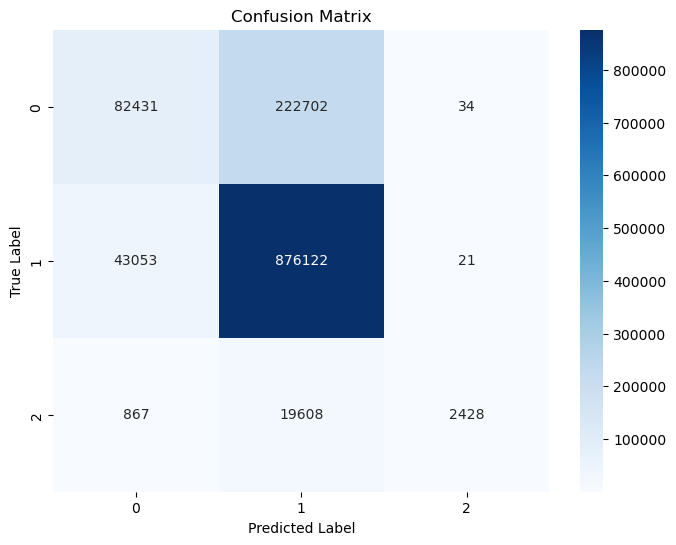

[[ 82431 222702     34]
 [ 43053 876122     21]
 [   867  19608   2428]]
Evaluating with top 10 features:
              precision    recall  f1-score   support

           0       0.27      0.63      0.38    129587
           1       0.95      0.78      0.86   1115420
           2       0.10      1.00      0.18      2259

    accuracy                           0.77   1247266
   macro avg       0.44      0.80      0.47   1247266
weighted avg       0.88      0.77      0.81   1247266



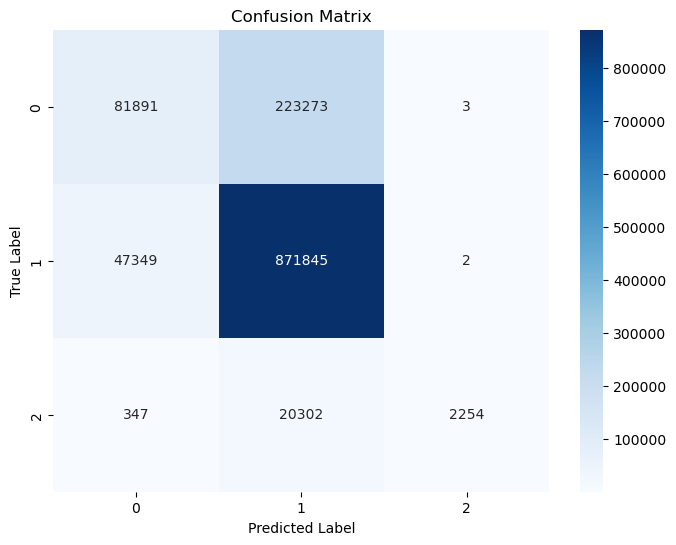

[[ 81891 223273      3]
 [ 47349 871845      2]
 [   347  20302   2254]]


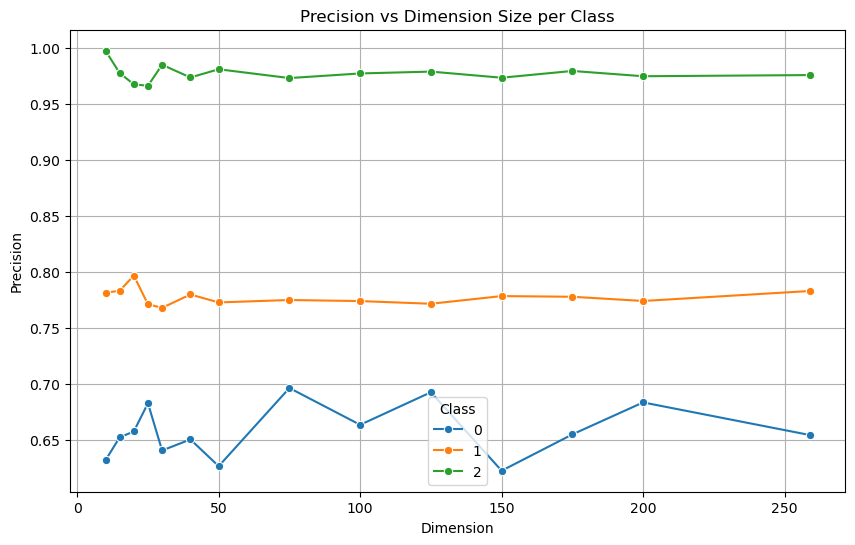

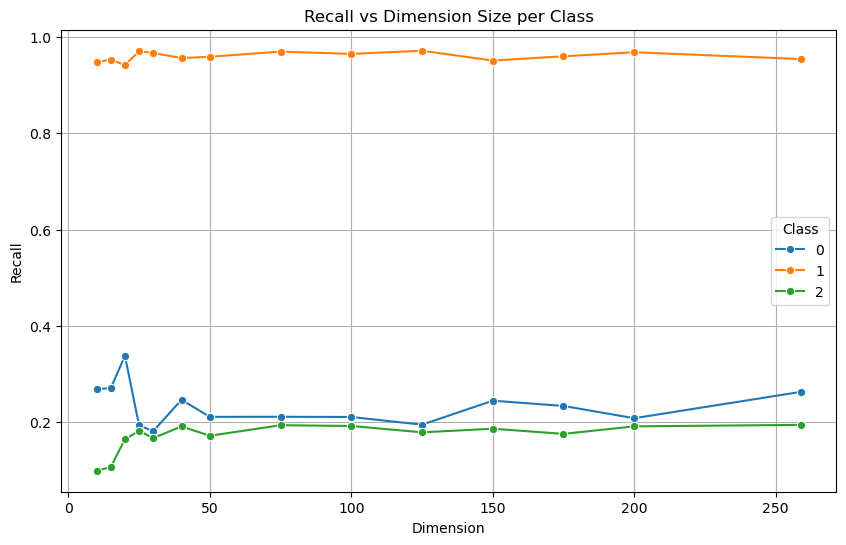

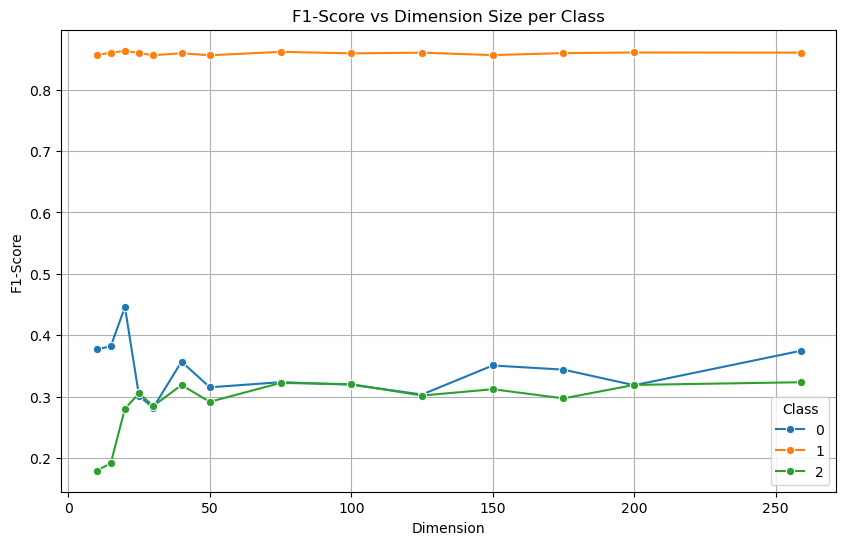

In [75]:
precision_list = []
recall_list = []
f1_list = []
x_col_size = [200, 175, 150, 125, 100, 75, 50, 40, 30, 25, 20, 15, 10]
xgbm = XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('gbtree'),
        alpha=0.8929914624140356,
        subsample=0.5245590585473099,
        colsample_bytree=0.41745486572446977,
        max_depth=10,
        eta=0.03343544751435021,
        gamma=0.36103800824329335,
        grow_policy='lossguide',
        min_child_weight=2,
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42,)
evaluate(xgbm, 259)


for len in x_col_size:
    print(f"Evaluating with top {len} features:")
    importances = xgbm.feature_importances_
    feature_importances = pd.DataFrame({'Feature': x_cols, 'Importance': importances})
    feature_importances = feature_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    top_features = feature_importances.head(len)
    top_feature_names = top_features['Feature'].tolist()
    x_cols = top_feature_names
    
    xgbm = XGBClassifier(
    objective='multi:softmax',num_class=3,booster=('gbtree'),alpha=0.8929914624140356, subsample=0.5245590585473099,colsample_bytree=0.41745486572446977,
        max_depth=10,eta=0.03343544751435021, gamma=0.36103800824329335,grow_policy='lossguide', min_child_weight=2, eval_metric='merror',  # Multi-class error for evaluation
        random_state=42,)
    evaluate(xgbm, len)

df = pd.DataFrame(precision_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="Precision", hue="Class", marker="o")
plt.title("Precision vs Dimension Size per Class")
plt.grid(True)
plt.show()

df = pd.DataFrame(recall_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="Recall", hue="Class", marker="o")
plt.title("Recall vs Dimension Size per Class")
plt.grid(True)
plt.show()

df = pd.DataFrame(f1_list)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Dimension", y="F1-Score", hue="Class", marker="o")
plt.title("F1-Score vs Dimension Size per Class")
plt.grid(True)
plt.show()